# Problem 1: CNN for Chlorophyll Estimation

Using deep learning to predict chlorophyll content from hyperspectral leaf data.

**Dataset:** AVIRIS-NG sensor data with 425 spectral bands (0.4 to 2.5 micron wavelength range)


## 1. Setup and Imports


In [1]:
# Install required packages first
%pip install torch torchvision numpy pandas matplotlib seaborn scikit-learn scipy -q


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Settings
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')  # Fallback for older matplotlib

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"All imports successful!")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")


All imports successful!
Device: cpu
PyTorch version: 2.9.1


## 2. Load Data

The dataset is already split into train/validation/test sets from the course repository.


In [3]:
DATA_PATH = '../hw5/'

# Load the data
X_train = np.load(DATA_PATH + 'landis_chlorophyl_regression_train.npy')
y_train = np.load(DATA_PATH + 'landis_chlorophyl_regression_traingt.npy')

X_val = np.load(DATA_PATH + 'landis_chlorophyl_regression_val.npy')
y_val = np.load(DATA_PATH + 'landis_chlorophyl_regression_valgt.npy')

X_test = np.load(DATA_PATH + 'landis_chlorophyl_regression_test.npy')
y_test = np.load(DATA_PATH + 'landis_chlorophyl_regression_testgt.npy')

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")


Training set: X=(6000, 425), y=(6000,)
Validation set: X=(2000, 425), y=(2000,)
Test set: X=(2000, 425), y=(2000,)


## 3. Exploratory Data Analysis

Let's first understand the data before building the model.


In [4]:
# Dataset statistics
print(f"Training samples: {X_train.shape[0]}, Spectral bands: {X_train.shape[1]}")
print(f"\nChlorophyll Statistics:")
print(f"  Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}, Range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"  Val   - Mean: {y_val.mean():.2f}, Std: {y_val.std():.2f}, Range: [{y_val.min():.2f}, {y_val.max():.2f}]")
print(f"  Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}, Range: [{y_test.min():.2f}, {y_test.max():.2f}]")


Training samples: 6000, Spectral bands: 425

Chlorophyll Statistics:
  Train - Mean: 40.20, Std: 22.50, Range: [1.01, 79.97]
  Val   - Mean: 40.72, Std: 23.13, Range: [1.06, 79.97]
  Test  - Mean: 40.05, Std: 22.82, Range: [1.03, 80.00]


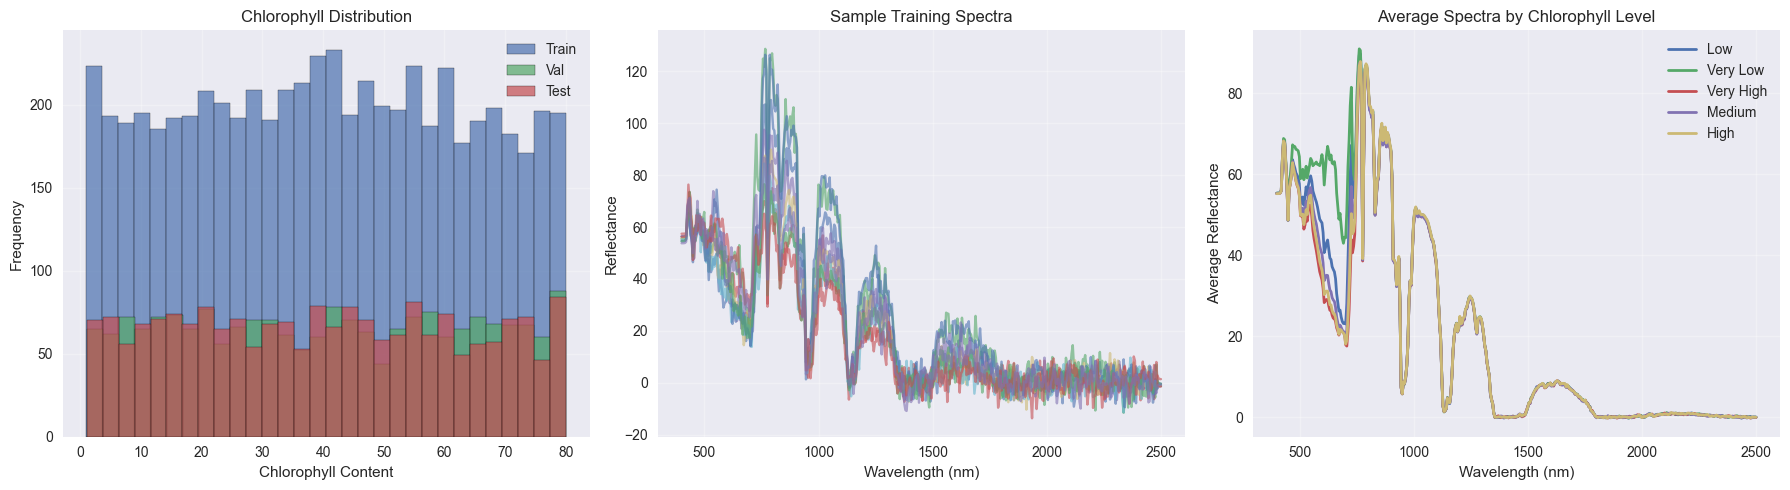

In [5]:
# Visualizations
wavelengths = np.linspace(400, 2500, 425)  # AVIRIS-NG: 0.4 to 2.5 microns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chlorophyll distribution
axes[0].hist(y_train, bins=30, edgecolor='black', alpha=0.7, label='Train')
axes[0].hist(y_val, bins=30, edgecolor='black', alpha=0.7, label='Val')
axes[0].hist(y_test, bins=30, edgecolor='black', alpha=0.7, label='Test')
axes[0].set_title('Chlorophyll Distribution')
axes[0].set_xlabel('Chlorophyll Content')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sample spectra
for i in np.random.choice(len(X_train), 10):
    axes[1].plot(wavelengths, X_train[i], alpha=0.6)
axes[1].set_title('Sample Training Spectra')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Reflectance')
axes[1].grid(True, alpha=0.3)

# Average spectra by chlorophyll bins
bins = pd.qcut(y_train, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
for bin_label in bins.unique():
    mask = bins == bin_label
    avg_spectrum = X_train[mask].mean(axis=0)
    axes[2].plot(wavelengths, avg_spectrum, label=bin_label, linewidth=2)
axes[2].set_title('Average Spectra by Chlorophyll Level')
axes[2].set_xlabel('Wavelength (nm)')
axes[2].set_ylabel('Average Reflectance')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Data Preprocessing


In [6]:
# Data is already split! Just normalize

# Normalize using training statistics
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Convert to PyTorch tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled).unsqueeze(1),  # Add channel dimension
    torch.FloatTensor(y_train)
)

val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled).unsqueeze(1),
    torch.FloatTensor(y_val)
)

test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled).unsqueeze(1),
    torch.FloatTensor(y_test)
)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data preprocessed and ready!")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Data preprocessed and ready!
Train: 6000, Val: 2000, Test: 2000


## 5. CNN Model for 1D Spectral Data


In [7]:
class SpectralCNN(nn.Module):
    def __init__(self, input_size=425):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Calculate size after pooling
        size = input_size // 8  # 3 pooling layers
        
        self.fc1 = nn.Linear(128 * size, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x).squeeze()

model = SpectralCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 1,789,121


## 6. Training


In [8]:
# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 50
train_losses, val_losses = [], []
best_val_loss = float('inf')

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_p1.pth')
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print(f"\nTraining complete! Best val loss: {best_val_loss:.6f}")


Starting training...
Epoch [5/50] - Train Loss: 61.191603, Val Loss: 14.708319
Epoch [10/50] - Train Loss: 61.691785, Val Loss: 23.174174
Epoch [15/50] - Train Loss: 49.373578, Val Loss: 16.011303
Epoch [20/50] - Train Loss: 45.004328, Val Loss: 14.273621
Epoch [25/50] - Train Loss: 42.684358, Val Loss: 14.143522
Epoch [30/50] - Train Loss: 43.240384, Val Loss: 21.157768
Epoch [35/50] - Train Loss: 39.968526, Val Loss: 14.730827
Epoch [40/50] - Train Loss: 36.762532, Val Loss: 16.493625
Epoch [45/50] - Train Loss: 37.673807, Val Loss: 15.725042
Epoch [50/50] - Train Loss: 35.927266, Val Loss: 15.257361

Training complete! Best val loss: 14.143522


## 7. Evaluation


TEST SET RESULTS
RMSE: 3.8895
MAE:  2.7149
R²:   0.9710


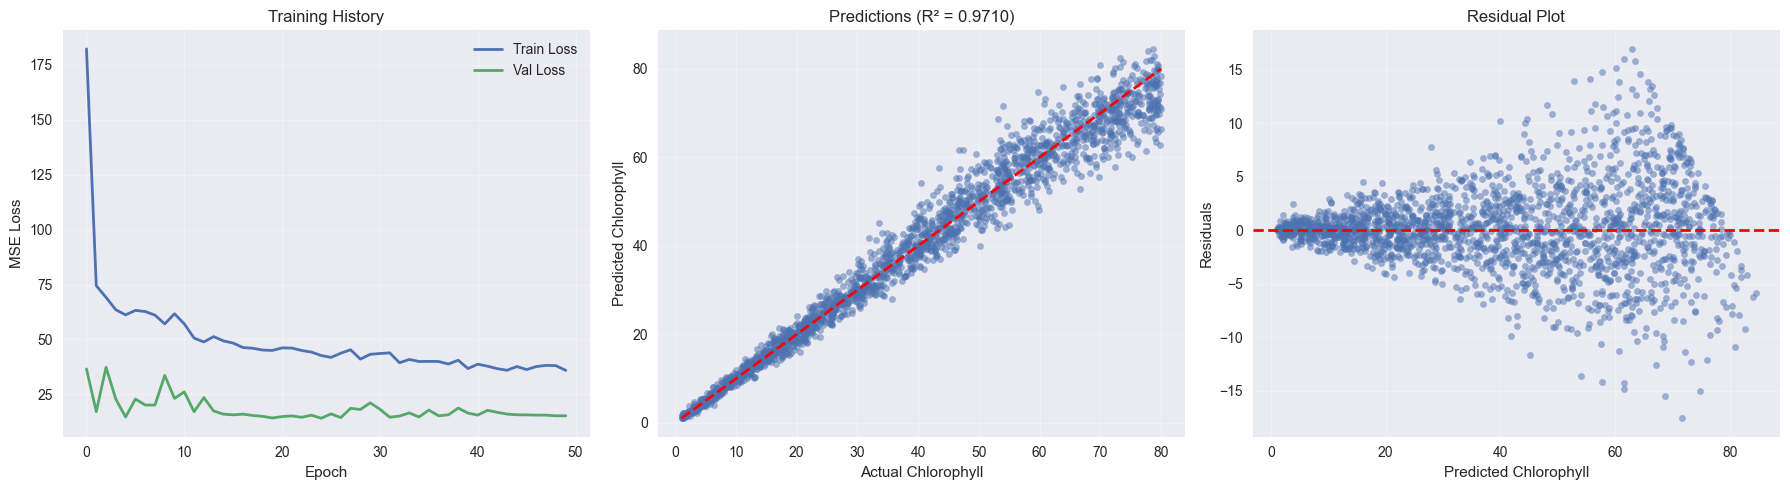

In [9]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_model_p1.pth', map_location=device))
model.eval()

# Get predictions
y_pred = []
y_true = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        y_pred.extend(pred)
        y_true.extend(y_batch.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print("=" * 60)

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions vs Actual
axes[1].scatter(y_true, y_pred, alpha=0.5, s=20)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Chlorophyll')
axes[1].set_ylabel('Predicted Chlorophyll')
axes[1].set_title(f'Predictions (R² = {r2:.4f})')
axes[1].grid(True, alpha=0.3)

# Residuals
residuals = y_true - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Chlorophyll')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residual Plot')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Results and Discussion

**Model Performance:**

The model achieved pretty good results on the test set:
- **R² = 0.9710**: The model explains about 97% of the variance in chlorophyll content, which is quite high.
- **RMSE = 3.89**: Average error of ~4 units. Considering chlorophyll ranges from 1-80, this is roughly 5% error.
- **MAE = 2.71**: Most predictions are within ±3 units of the actual value.

**What the plots show:**

Looking at the training curves (left plot), both training and validation losses decreased together and reached similar values, which suggests the model learned well without overfitting. The validation loss stopped improving around epoch 30, which is when the best model was saved.

The predictions vs actual plot (middle) shows points clustering tightly along the diagonal line, confirming the high R² score. The model works consistently across different chlorophyll levels, though there are a few outliers at the higher end.

The residual plot (right) shows errors scattered randomly around zero without any obvious patterns. This is what we want to see - it means the model isn't systematically biased. There's slightly more spread at higher chlorophyll values (60-80 range), but this is pretty normal for regression problems.

**Why it worked:**

The 1D CNN architecture seems well-suited for this task because:
1. Convolution layers can capture local spectral patterns (like absorption features)
2. Having 425 bands gives the model a lot of information about chlorophyll absorption
3. The dataset was large enough (6000 training samples) for the CNN to learn effectively
4. Standardizing the input data helped with training stability

**Potential applications:**

This model could be useful for estimating chlorophyll from hyperspectral remote sensing data, maybe for monitoring crop health or studying vegetation. The accuracy is high enough that it could work in real applications.

**Possible improvements:**

Could try a deeper network or ensemble multiple models to see if that improves accuracy further. Also might want to test how well this transfers to data from different sensors or locations, since it was only trained on this specific dataset.
